In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
ticker = 'VUAA.L'
df = yf.download(ticker, '2020-01-01')

C:\Users\reide\AppData\Local\Temp\ipykernel_13864\3735677197.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [10]:
df

Price,Close,High,Low,Open,Volume
Ticker,VUAA.L,VUAA.L,VUAA.L,VUAA.L,VUAA.L
Date,,,,,
2020-01-02,57.764999,57.970001,57.820000,57.919998,32050
2020-01-03,57.650002,57.730999,57.480000,57.480000,6062
2020-01-06,57.630001,57.750000,57.220001,57.750000,5014
2020-01-07,57.830002,57.860001,57.655998,57.750000,9681
2020-01-08,57.930000,57.880001,57.639999,57.700001,13285
...,...,...,...,...,...
2025-08-29,123.639999,124.480003,123.400002,124.440002,107396
2025-09-01,123.940002,123.980003,123.639999,123.699997,62265


<Axes: xlabel='Date'>

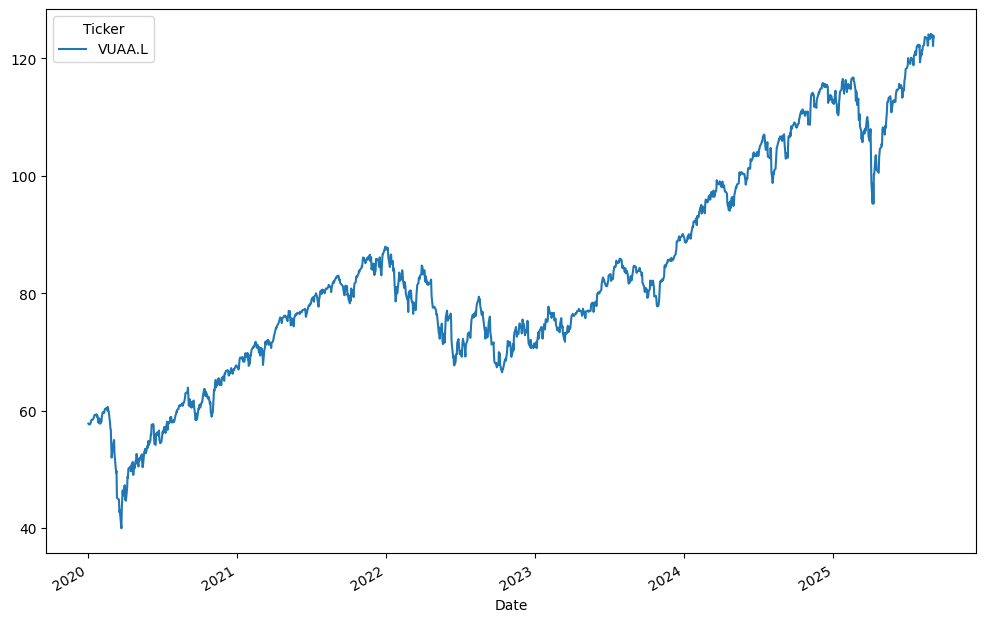

In [12]:
df.Close.plot(figsize= (12, 8))

In [13]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [14]:
df.Close

Ticker,VUAA.L
Date,
2020-01-02,-1.358227
2020-01-03,-1.364424
2020-01-06,-1.365501
2020-01-07,-1.354725
2020-01-08,-1.349337
...,...
2025-08-29,2.191258
2025-09-01,2.207423
2025-09-02,2.107202


In [16]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data =np.array(data)

In [17]:
data

array([[[-1.35822749],
        [-1.36442383],
        [-1.36550149],
        ...,
        [-1.25881488],
        [-1.23106561],
        [-1.22271395]],

       [[-1.36442383],
        [-1.36550149],
        [-1.35472502],
        ...,
        [-1.23106561],
        [-1.22271395],
        [-1.22109734]],

       [[-1.36550149],
        [-1.35472502],
        [-1.34933689],
        ...,
        [-1.22271395],
        [-1.22109734],
        [-1.22001967]],

       ...,

       [[ 2.05978592],
        [ 2.02314605],
        [ 2.05116499],
        ...,
        [ 2.21927741],
        [ 2.19125847],
        [ 2.20742328]],

       [[ 2.02314605],
        [ 2.05116499],
        [ 2.09858113],
        ...,
        [ 2.19125847],
        [ 2.20742328],
        [ 2.10720247]],

       [[ 2.05116499],
        [ 2.09858113],
        [ 2.10720247],
        ...,
        [ 2.20742328],
        [ 2.10720247],
        [ 2.16862807]]], shape=(1403, 30, 1))

In [19]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :])
y_train = torch.from_numpy(data[:train_size, -1, :])
X_test = torch.from_numpy(data[train_size:, :-1, :])
y_test = torch.from_numpy(data[:train_size:, -1, :])

In [22]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm =nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out= self.fc(out[:, -1, :])

        return out

In [23]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [24]:
criterion = nn.MSELoss()
optimizer =optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    